In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
# load in dataset with monthly t2m means across the globe from 1985-2014
t2m_means = xr.open_dataset('/home/alawyer2/era5-data/all-monthly-means.nc')

# load in original data to compare with means
years = range(1985, 2015) 
directory_path = '/projects/lortizur/cop_climate/era5/'
files_list = [directory_path+f for f in os.listdir(directory_path) if int(f[-10:-6]) in years]
ds = xr.open_mfdataset(files_list)

# convert K to ºC
ds['t2m'] = (ds['t2m'] - 273.15).assign_attrs(units='degC')

# calculate anomalies 
t2m_anoms = ds.groupby('time.month') - t2m_means
t2m_anoms 

<xarray.Dataset> Size: 46GB
Dimensions:      (time: 10957, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 88kB 1985-01-01 1985-01-02 ... 2014-12-31
    realization  (time) int64 88kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    month        (time) int64 88kB 1 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12 12
Data variables:
    t2m          (time, lat, lon) float32 46GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>

In [3]:
# load in AMO (Atlantic Multidecadal Oscillation) Index dataset, downloaded from https://psl.noaa.gov/data/timeseries/AMO/ 
# data are sst anomalies for Atlantic ocean. Anomalies are based on the 1951-1980 time period. 
amo_data_table = pd.read_table('/home/alawyer2/amo-data/amon.sm.data', sep=' ', skipinitialspace=True, 
                        header=None, skiprows=[0],
                        names={'year': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12},
                        skipfooter=10, # 2018-2023 are nearly all -99.99 values, so skipping these years since my data ends at 2014
                        na_values='-99.99', engine='python')

# format table into timeseries structure before converting to xarray ds. copilot helped give direction, then I modified to produce what I wanted to see
amo_long = amo_data_table.melt(id_vars='year', var_name='month', value_name='sst')
amo_long['time'] = pd.to_datetime({'year': amo_long['year'], 'month': amo_long['month'], 'day':1})
amo_ts = amo_long.set_index('time').sort_index()['sst'].to_frame()

amo_ds = amo_ts.to_xarray()
amo_ds

<xarray.Dataset> Size: 13kB
Dimensions:  (time: 840)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1948-01-01 1948-02-01 ... 2017-12-01
Data variables:
    sst      (time) float64 7kB 0.101 0.101 0.101 0.105 ... 0.177 0.176 0.177

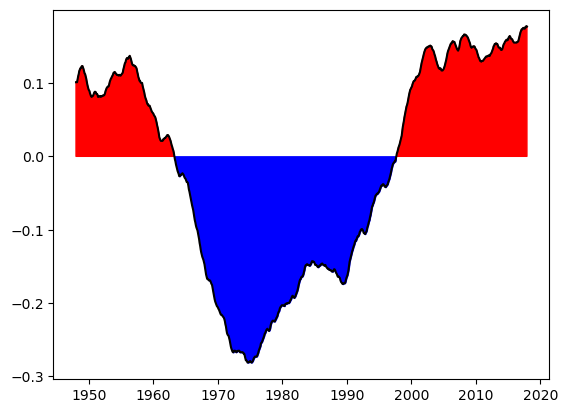

In [4]:
# define positive and negative phases of AMO, as described here: 
# https://climatedataguide.ucar.edu/climate-data/atlantic-multi-decadal-oscillation-amo
pos_amo = amo_ds['sst'].where(amo_ds['sst'] > 0)
neg_amo = amo_ds['sst'].where(amo_ds['sst'] < 0)

# plot AMO sst values over time
plt.plot(amo_ds['time'], amo_ds['sst'], 'k')
plt.fill_between(amo_ds['time'].values, pos_amo, color='red')
plt.fill_between(amo_ds['time'].values, neg_amo, color='blue')

In [5]:
# limit AMO data timeframe to match available t2m data 
pos_lim = pos_amo.sel(time=slice(t2m_anoms['time'][0], t2m_anoms['time'][-1]))
neg_lim = neg_amo.sel(time=slice(t2m_anoms['time'][0], t2m_anoms['time'][-1]))

# find mean of t2m values conditioned on AMO phases, and compute since they're large enough to be dask arrays
pos_temps = t2m_anoms['t2m'].sel(time=pos_lim.dropna(dim='time')['time']).mean(dim='time').compute()
neg_temps = t2m_anoms['t2m'].sel(time=neg_lim.dropna(dim='time')['time']).mean(dim='time').compute()

composite_temps = {'pos_temps': pos_temps, 'neg_temps': neg_temps}
composite_temps

{'pos_temps': <xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 4MB
 array([[-0.45149666, -0.45149666, -0.45149666, ..., -0.45149666,
         -0.45149666, -0.45149666],
        [-0.35713357, -0.35715953, -0.35716227, ..., -0.35706937,
         -0.35715342, -0.35709834],
        [-0.3061839 , -0.3059199 , -0.30562598, ..., -0.30717924,
         -0.3067773 , -0.3065764 ],
        ...,
        [ 0.28261223,  0.28249523,  0.28238356, ...,  0.28302592,
          0.28280032,  0.28273907],
        [ 0.2542085 ,  0.2541387 ,  0.25402135, ...,  0.25441104,
          0.2543419 ,  0.25425163],
        [ 0.2380875 ,  0.2380875 ,  0.2380875 , ...,  0.2380875 ,
          0.2380875 ,  0.2380875 ]], dtype=float32)
 Coordinates:
   * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
   * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8,
 'neg_temps': <xarray.DataArray 't2m' (lat: 721, lon: 1440)> Size: 4MB
 array([[ 0.8369992 ,  0.8369992 ,  0.8369992 , 

In [10]:
counts=[pos_lim.count(dim='time').values, neg_lim.count(dim='time').values]

Text(0.5, 0.98, 'Composite 2m Temperature Anomalies during AMO')

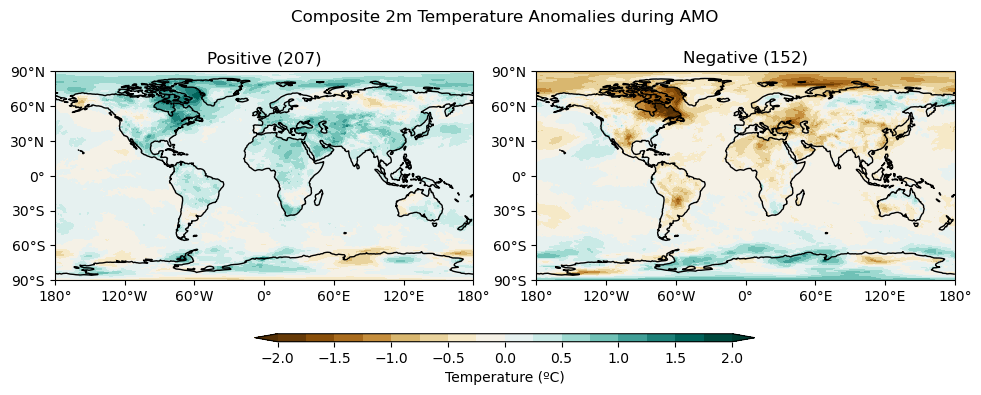

In [43]:
labels = ['Positive', 'Negative']
clevs = np.arange(-2.0, 2.1, 0.25)

# Define the figure and each axis for the 1 row and 2 columns
fig, axs = plt.subplots(nrows=1, ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(10, 4))

# Loop over both phases and plot
for i, temp in enumerate(composite_temps):
        data = composite_temps[temp]

        data, lons = add_cyclic_point(data, coord=composite_temps[temp]['lon'])
        cs = axs[i].contourf(lons, composite_temps[temp]['lat'], data, clevs,
                          transform = ccrs.PlateCarree(),
                          cmap='BrBG', extend='both') 

        axs[i].set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
        lon_formatter = cticker.LongitudeFormatter()
        axs[i].xaxis.set_major_formatter(lon_formatter)

        axs[i].set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
        lat_formatter = cticker.LatitudeFormatter()
        axs[i].yaxis.set_major_formatter(lat_formatter)

        axs[i].set_title(labels[i]+' ('+str(counts[i])+')')

        axs[i].coastlines()

# Adjust subplot spacing
fig.subplots_adjust(bottom=0.25, left=0.05, right=0.95,
                    wspace=0.15, hspace=0.5)

# Add a colorbar 
cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.02])
cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal', label='Temperature (ºC)')

plt.suptitle('Composite 2m Temperature Anomalies during AMO')